SOAL 3: MODELING & EVALUATION 

Muat Data Bersih

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

# Load data hasil ekspor dari notebook 01
X_train, X_test, y_train, y_test, scaler = joblib.load('../data/processed/clean_data.pkl')
print("✓ Data latih dan data uji berhasil dimuat!")

✓ Data latih dan data uji berhasil dimuat!


Pelatihan Model 1 - Random Forest + Hyperparameter Tuning

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

print("Melatih Model 1: Random Forest...")
rf_base = RandomForestRegressor(random_state=42)
rf_param = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}

# Menggunakan RandomizedSearchCV agar proses komputasi lokal lebih cepat
rf_search = RandomizedSearchCV(rf_base, rf_param, n_iter=2, cv=3, random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print("✓ Model Random Forest selesai dilatih dan dituning.")

Melatih Model 1: Random Forest...
✓ Model Random Forest selesai dilatih dan dituning.


Pelatihan Model 2 - XGBoost + Hyperparameter Tuning

In [4]:
from xgboost import XGBRegressor

print("Melatih Model 2: XGBoost...")
xgb_base = XGBRegressor(random_state=42)
xgb_param = {'n_estimators': [100, 200], 'max_depth': [4, 6, 8], 'learning_rate': [0.1, 0.2]}

xgb_search = RandomizedSearchCV(xgb_base, xgb_param, n_iter=2, cv=3, random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print("✓ Model XGBoost selesai dilatih dan dituning.")

Melatih Model 2: XGBoost...
✓ Model XGBoost selesai dilatih dan dituning.


Evaluasi Komprehensif & Tabel Perbandingan

In [5]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate(model, X, y):
    preds = model.predict(X)
    r2 = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    return r2, mae, rmse, preds

# Evaluasi kedua model pada Test Data
rf_r2, rf_mae, rf_rmse, rf_preds = evaluate(best_rf, X_test, y_test)
xgb_r2, xgb_mae, xgb_rmse, xgb_preds = evaluate(best_xgb, X_test, y_test)

# Cetak Ringkasan Tabel Perbandingan Performa
summary = pd.DataFrame({
    'Metrik': ['R2 Score (Akurasi)', 'MAE (Error)', 'RMSE (Error)'],
    'Random Forest': [rf_r2, rf_mae, rf_rmse],
    'XGBoost': [xgb_r2, xgb_mae, xgb_rmse]
})
print(summary.to_string(index=False))

# Tentukan model terbaik secara otomatis
best_model = best_xgb if xgb_r2 > rf_r2 else best_rf
best_preds = xgb_preds if xgb_r2 > rf_r2 else rf_preds
print(f"\nModel Terbaik yang Dipilih: {'XGBoost' if xgb_r2 > rf_r2 else 'Random Forest'}")

            Metrik  Random Forest  XGBoost
R2 Score (Akurasi)       0.994281 0.994825
       MAE (Error)       2.523324 2.196477
      RMSE (Error)       4.543057 4.321400

Model Terbaik yang Dipilih: XGBoost


Visualisasi Hasil Prediksi Model Terbaik

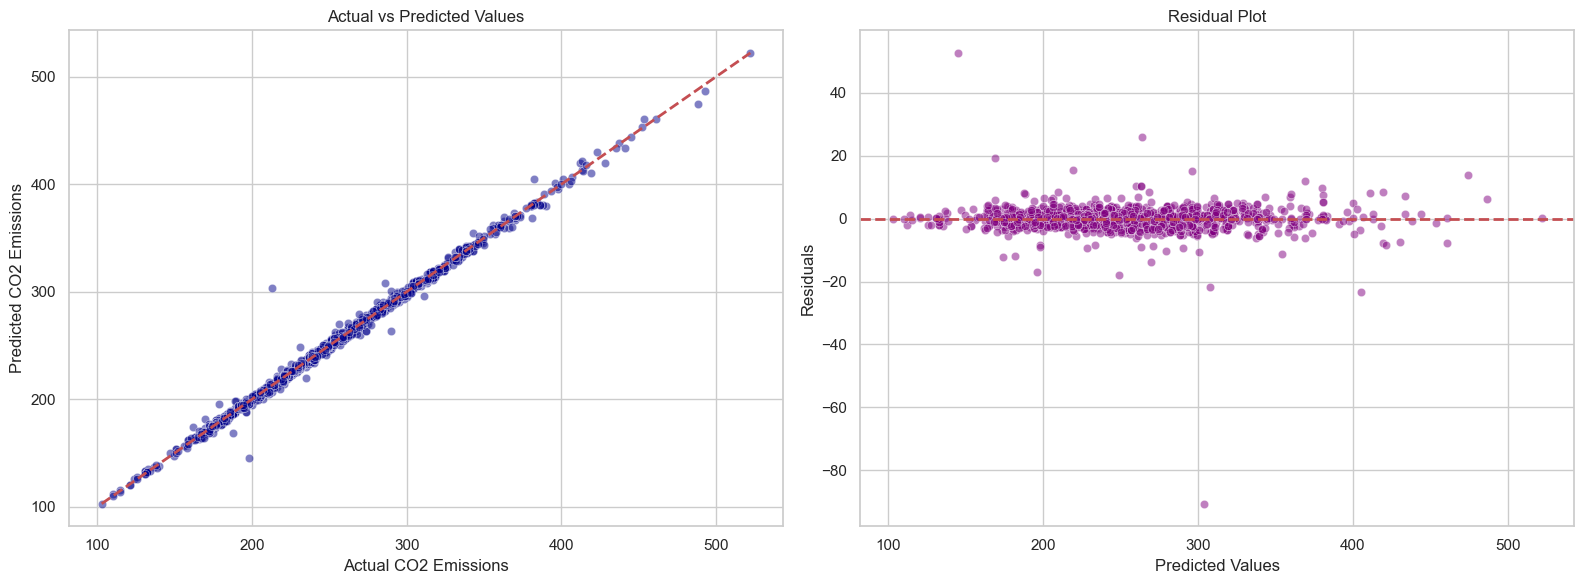

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test, y=best_preds, alpha=0.5, color='darkblue', ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Values')
axes[0].set_xlabel('Actual CO2 Emissions')
axes[0].set_ylabel('Predicted CO2 Emissions')

# Plot 2: Residual Plot
residuals = y_test - best_preds
sns.scatterplot(x=best_preds, y=residuals, alpha=0.5, color='purple', ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

Eksper Model Final ke Folder models/

In [7]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler, '../models/preprocessing.pkl')
print("✓ Berkas 'best_model.pkl' dan 'preprocessing.pkl' siap digunakan untuk aplikasi Streamlit!")

✓ Berkas 'best_model.pkl' dan 'preprocessing.pkl' siap digunakan untuk aplikasi Streamlit!
